In [149]:
import sys
import subprocess

# subprocess.check_call([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "XlsxWriter"
# ])

import xlsxwriter

# uploaad nessery packages
import os 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
import seaborn as sns


import numpy as np


from scikit_posthocs import posthoc_dunn as dunn
from scipy.stats import mannwhitneyu, false_discovery_control, kruskal, spearmanr

path = os.path.dirname(os.getcwd()).replace('\\', '/') + '/data/'
plot_path = os.path.dirname(os.getcwd()).replace('\\', '/') + '/Plots/'


sns.set_theme(style="whitegrid")



def sinificant_bold_red(val):
    """
    Applies 'font-weight: bold' and 'color: red' if P-value below 0.05.
    """
    if isinstance(val, (int, float)):
        color = "#AA0000" if val <= 0.055 else "#AFAFAF"
        font_weight = 'bold' if val <= 0.055 else 'normal' 
        return f'color: {color}; font-weight: {font_weight}'
        
    return ''


def sinificant_bold_red_for_excel(val):
    """
    Applies 'font-weight: bold' and 'color: red' if P-value below 0.05.
    """
    if isinstance(val, (int, float)):
        color = "#AA0000" if val <= 0.055 else "#000000"
        font_weight = 'bold' if val <= 0.055 else 'normal' 
        return f'color: {color}; font-weight: {font_weight}'
        
    return ''

In [92]:
# Upload fluke data
fluke_data = pd.read_excel(path + 'data_four_species.xlsx', 
                           sheet_name='fluke_data').drop('ID', axis=1)
display(fluke_data)

,animal_group,timepoint,liver_flukes,flukes_per_mass,eggs_in_feces,eggs_per_flukes
0,wistar,1_month,0,0.0,0,0.0
1,wistar,1_month,0,0.0,0,0.0
2,wistar,1_month,0,0.0,0,0.0
3,wistar,1_month,0,0.0,0,0.0
4,wistar,1_month,0,0.0,0,0.0
5,balb,1_month,0,0.0,0,0.0
6,balb,1_month,0,0.0,0,0.0
7,balb,1_month,0,0.0,0,0.0
8,balb,1_month,0,0.0,0,0.0
9,balb,1_month,1,0.8,0,0.0


## Additional functions

### Function for boxplot recoloring

In [93]:
def recolor_boxes_by_position(current_ax, group_order, group_colors):
    current_ax.figure.canvas.draw()

    renderer = current_ax.figure.canvas.get_renderer()

    box_patches = [
        patch
        for patch in current_ax.patches
        if isinstance(patch, PathPatch)
    ]

    boxes_by_group = {
        group_index: []
        for group_index in range(len(group_order))
    }

    # Find the horizontal position of each box
    for patch in box_patches:
        bbox = patch.get_window_extent(renderer=renderer)

        center_display = (
            (bbox.x0 + bbox.x1) / 2,
            (bbox.y0 + bbox.y1) / 2
        )

        center_data = current_ax.transData.inverted().transform(
            center_display
        )

        x_position = center_data[0]

        # Assign box to the nearest animal-group position
        group_index = min(
            range(len(group_order)),
            key=lambda i: abs(i - x_position)
        )

        boxes_by_group[group_index].append(
            (x_position, patch)
        )

    # Sort boxes left-to-right and apply colors
    for group_index, group in enumerate(group_order):

        group_boxes = sorted(
            boxes_by_group[group_index],
            key=lambda item: item[0]
        )

        expected_number = len(group_colors[group])

        if len(group_boxes) != expected_number:
            print(
                f"Warning: {group} has {len(group_boxes)} boxes, "
                f"but {expected_number} colors were provided."
            )

        for patch_number, (_, patch) in enumerate(group_boxes):
            if patch_number >= expected_number:
                break

            patch.set_facecolor(
                group_colors[group][patch_number]
            )
            patch.set_edgecolor("black")
            patch.set_alpha(0.7)

### Creates recolored boxplot with stripplot

In [94]:
# Creates boxplot wih stripplot
def box_strip_plot(data, x, y, hue, ax, xtick_labels, xtick_number=[0, 1, 2, 3],
                   palette='Paired', order=None, hue_order=None, dodge=True):
    
    
    sns.boxplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax,  
                legend=False, showfliers=False, boxprops={'alpha': 0.85,
                                                          'linewidth': 1.5},
                medianprops={'linewidth': 2}, order=order, hue_order=hue_order)
    
    
    recolor_boxes_by_position(
                current_ax,
                group_order,
                pair_colors)
    
    
        
    sns.stripplot(data=data, x=x, y=y,  ax=ax,
                  legend=False, hue=hue, palette=palette, dodge=dodge,
                  edgecolor='black', linewidth=0.5, alpha=0.85, order=order)  
    
    
    ax.set_xticks(xtick_number, labels=xtick_labels)
    ax.set_xlabel('')  

## Investigation of parasite burden 

### Compare animal groups withing each month

In [95]:
for month in fluke_data['timepoint'].unique():
    
    mask_1 = fluke_data['timepoint'] == month
    temp_data = fluke_data[mask_1]


    wistar, balb, black, hamster = [temp_data[temp_data['animal_group'] == i] \
        for i in temp_data['animal_group'].unique()]

    for col in temp_data.columns[2:]:
        
        print(f'Duration is {month}')
        print(f'Kruscal p-value for {col}')
        print(f'{kruskal(wistar[col], balb[col], 
                        black[col], hamster[col]).pvalue:.4f}\n')
    
        
        dunn_results = dunn(a=temp_data, 
                            group_col='animal_group', 
                            val_col=col,
                            p_adjust='fdr_bh')
        
        styled_dunn = \
            dunn_results.style.map(sinificant_bold_red).format('{:.3f}')
        
        print("Dunn's post-hoc values with fdr-bh:" )
        display(styled_dunn)


Duration is 1_month
Kruscal p-value for liver_flukes
0.0018

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,1.000,0.006,0.765
black,1.000,1.000,0.006,0.765
hamster,0.006,0.006,1.000,0.003
wistar,0.765,0.765,0.003,1.000


Duration is 1_month
Kruscal p-value for flukes_per_mass
0.0018

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.950,0.006,0.793
black,0.950,1.000,0.006,0.793
hamster,0.006,0.006,1.000,0.003
wistar,0.793,0.793,0.003,1.000


Duration is 1_month
Kruscal p-value for eggs_in_feces
0.0012

Dunn's post-hoc values with fdr-bh:


...

,balb,black,hamster,wistar
balb,1.000,0.214,0.142,0.150
black,0.214,1.000,0.647,0.008
hamster,0.142,0.647,1.000,0.003
wistar,0.150,0.008,0.003,1.000


Duration is 3_month
Kruscal p-value for eggs_in_feces
0.0015

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.338,0.015,0.362
black,0.338,1.000,0.123,0.094
hamster,0.015,0.123,1.000,0.001
wistar,0.362,0.094,0.001,1.000


Duration is 3_month
Kruscal p-value for eggs_per_flukes
0.0030

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.815,0.018,0.536
black,0.815,1.000,0.024,0.480
hamster,0.018,0.024,1.000,0.003
wistar,0.536,0.480,0.003,1.000


### Compare animal withing one group (1st month vs 3rd month)

In [96]:
# Subset data for each animal
wistar, balb, black, hamster = [fluke_data[fluke_data['animal_group'] == i] \
        for i in fluke_data['animal_group'].unique()]

# Create empty list for p-values 
p_values=[]

# Cycle that calculate MWU-test for each parameter
for animal in [wistar, balb, black, hamster]:
    
    x=animal[animal['timepoint'] == '1_month']
    y=animal[animal['timepoint'] == '3_month']

    for col in animal.columns[2:]:
        mwu_result = mannwhitneyu(x[col], y[col]).pvalue
        p_values.append(mwu_result)
             
             
# Apply correction for multiple comparations 
p_values = false_discovery_control(p_values, method='bh')
  

# Display the result
for animal in [wistar, balb, black, hamster]: 
    print(f'1 vs 3 months for animal: \033[1m{animal['animal_group'].unique()[0]}\033[0m')


    # Display results of corrected MWU-test
    for index, col in enumerate(animal.columns[2:]):
        print(f'For parameter:\033[1m{col}\033[0m Mann-Whitney result: \033[1m{p_values[index]:.3f}\033[0m')   
        
    # Removes first 4 values from p-value
    p_values = p_values[4:]
    print()

1 vs 3 months for animal: wistar
For parameter:liver_flukes Mann-Whitney result: 1.000
For parameter:flukes_per_mass Mann-Whitney result: 1.000
For parameter:eggs_in_feces Mann-Whitney result: 1.000
For parameter:eggs_per_flukes Mann-Whitney result: 1.000

1 vs 3 months for animal: balb
For parameter:liver_flukes Mann-Whitney result: 0.128
For parameter:flukes_per_mass Mann-Whitney result: 0.083
For parameter:eggs_in_feces Mann-Whitney result: 0.128
For parameter:eggs_per_flukes Mann-Whitney result: 0.261

1 vs 3 months for animal: black
For parameter:liver_flukes Mann-Whitney result: 0.038
For parameter:flukes_per_mass Mann-Whitney result: 0.038
For parameter:eggs_in_feces Mann-Whitney result: 0.128
For parameter:eggs_per_flukes Mann-Whitney result: 0.261

1 vs 3 months for animal: hamster
For parameter:liver_flukes Mann-Whitney result: 0.038
For parameter:flukes_per_mass Mann-Whitney result: 0.296
For parameter:eggs_in_feces Mann-Whitney result: 0.038
For parameter:eggs_per_flukes Ma

### Display the result with boxplots

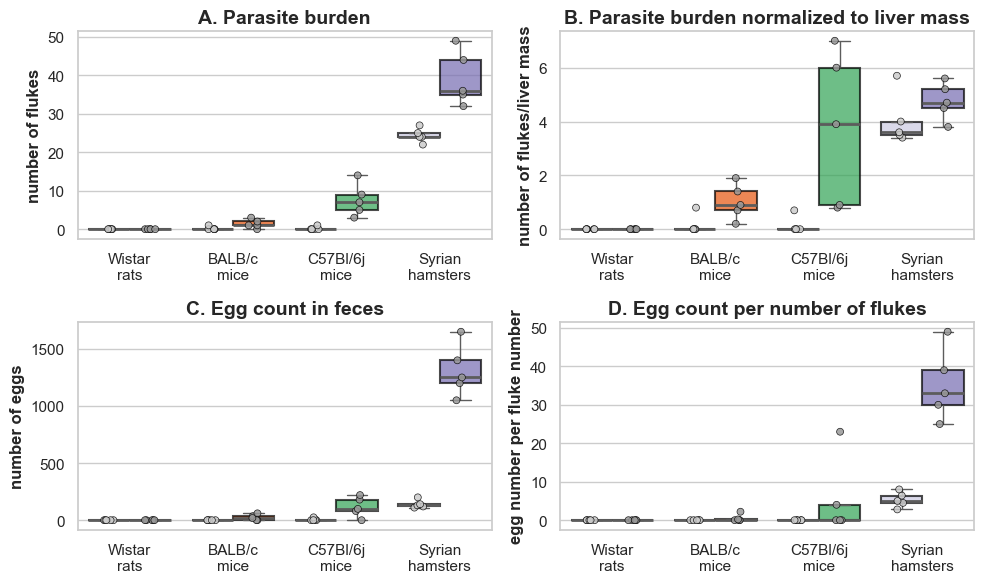

In [97]:
titles = ['A. Parasite burden', 'B. Parasite burden normalized to liver mass',
          'C. Egg count in feces', 'D. Egg count per number of flukes']

mesure_lst =['number of flukes', 'number of flukes/liver mass', 
             'number of eggs', 'egg number per fluke number']


x_axis_names = ['Wistar\nrats', 'BALB/c\nmice', 'C57Bl/6j\nmice', 'Syrian\nhamsters']


# Set colors for boxes
group_order = ["wistar", "balb", "black", "hamster"]
time_order = ["1_month", "3_month"]

pair_colors = {
    "wistar":  ["#9ecae1", "#3182bd"],
    "balb":    ["#fdae6b", "#e6550d"],
    "black":   ["#a1d99b", "#31a354"],
    "hamster": ["#cbc9e2", "#756bb1"],
}

timepoint_palette = {
    "1_month": "#cccccc",
    "3_month": "#999999"
}


fig, ax = plt.subplots(2, 2, figsize=(10, 6))


for index, column in enumerate(fluke_data.columns[2:]):

    current_ax = ax[index // 2, index % 2]
    
    if index < 2:
        box_strip_plot(data=fluke_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[0, index],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)
        
        ax[0, index].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[0, index].set_xlabel('')
        ax[0, index].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')




    else: 
        box_strip_plot(data=fluke_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[1, index-2],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)


        ax[1, index-2].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[1, index-2].set_xlabel('')
        ax[1, index-2].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

fig.tight_layout()

plt.savefig(plot_path+"Figure_2_eggs_and_worms/parasite_plot", dpi=300, bbox_inches="tight")

## Investigation of liver data

In [98]:
liver_data = pd.read_excel(path + 'data_four_species.xlsx', 
                           sheet_name='liver_data').drop('ID', axis=1)
display(liver_data)

,animal_group,timepoint,hyperplasia,inflammation,PF,ChF,AST,ALT
0,wistar,control,0.1,0.1,0.1,0.0,13,12
1,wistar,control,0.4,0.0,0.3,0.2,18,20
2,wistar,control,0.5,0.2,0.2,0.2,21,22
3,wistar,control,0.7,0.3,0.1,0.4,21,24
4,wistar,control,0.9,0.5,0.3,0.6,23,26
5,wistar,1_month,0.0,0.4,1.8,0.0,20,22
6,wistar,1_month,0.1,0.5,2.0,0.1,21,23
7,wistar,1_month,0.2,0.5,2.5,0.2,22,23
8,wistar,1_month,0.3,0.7,3.0,0.4,22,24
9,wistar,1_month,0.4,0.9,3.2,0.2,23,30


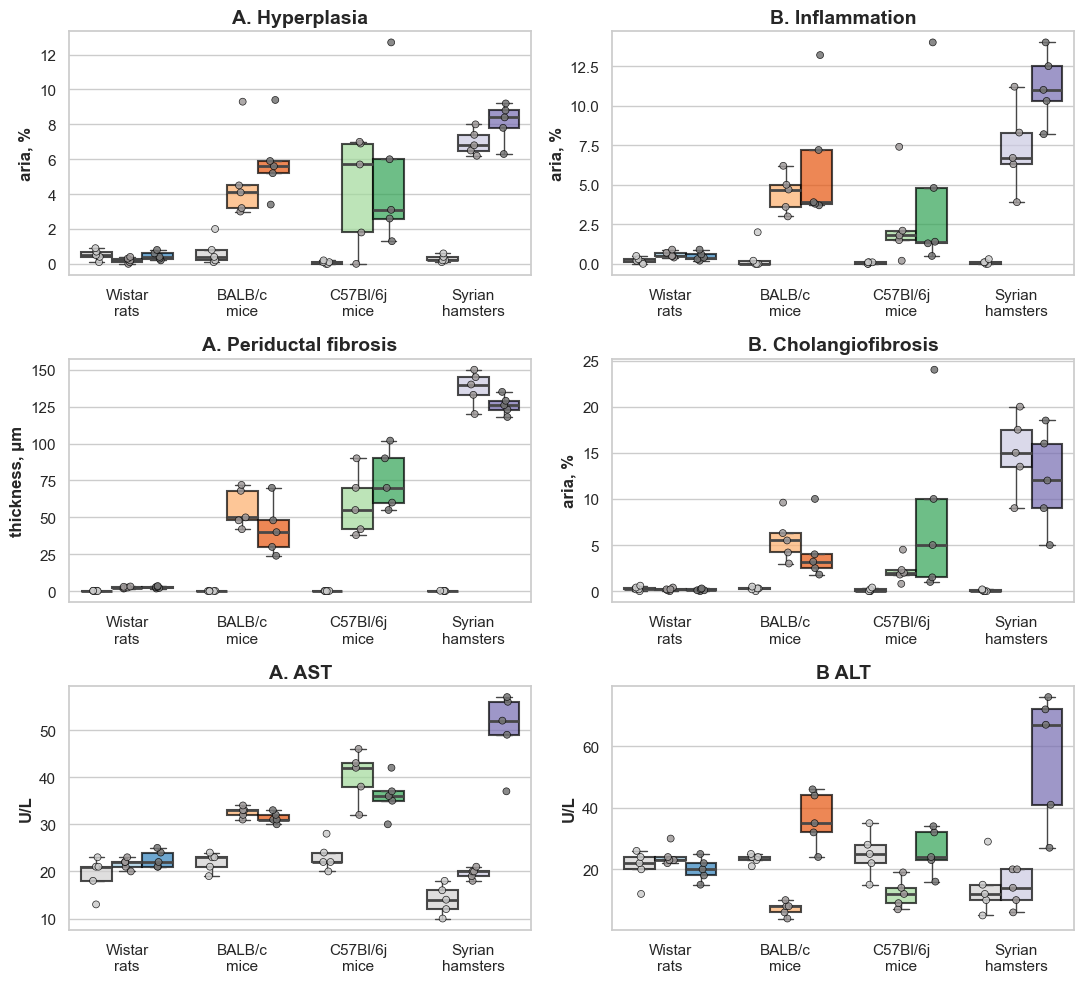

In [104]:
titles = ['A. Hyperplasia', 'B. Inflammation', 'A. Periductal fibrosis',
          'B. Cholangiofibrosis', 'A. AST', 'B ALT']

mesure_lst =['aria, %', 'aria, %', 'thickness, μm', 'aria, %', 'U/L', 'U/L']


x_axis_names = ['Wistar\nrats', 'BALB/c\nmice', 'C57Bl/6j\nmice', 'Syrian\nhamsters']


# Set colors for boxes
group_order = ["wistar", "balb", "black", "hamster"]
time_order = ["control", "1_month", "3_month"]

pair_colors = {
    "wistar":  ["#d2d0d0", "#9ecae1", "#3182bd"],
    "balb":    ["#d2d0d0", "#fdae6b", "#e6550d"],
    "black":   ["#d2d0d0", "#a1d99b", "#31a354"],
    "hamster": ["#d2d0d0", "#cbc9e2", "#756bb1"],
}

timepoint_palette = {
    "control": "#cccccc",
    "1_month": "#9f9a9a",
    "3_month": "#767676"
}


fig, ax = plt.subplots(3, 2, figsize=(11, 10))


for index, column in enumerate(liver_data.columns[2:]):

    current_ax = ax[index // 2, index % 2]
    
    if index < 2:
        box_strip_plot(data=liver_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[0, index],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)
        
        ax[0, index].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[0, index].set_xlabel('')
        ax[0, index].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')
        
        
    elif index >= 2 and index < 4:
            box_strip_plot(data=liver_data, x='animal_group', 
                        y=column, hue='timepoint', ax=ax[1, index-2],                   
                        palette=timepoint_palette, order=group_order, 
                        hue_order=time_order, xtick_labels=x_axis_names)
            
            ax[1, index-2].set_title(titles[index], fontsize=14, fontweight='bold')
            ax[1, index-2].set_xlabel('')
            ax[1, index-2].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')


    else: 
        box_strip_plot(data=liver_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[2, index-4],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)


        ax[2, index-4].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[2, index-4].set_xlabel('')
        ax[2, index-4].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

fig.tight_layout()

plt.savefig(plot_path+"Figure_4_ast_alt_fibrosis/hystology_plot", dpi=300, bbox_inches="tight")

In [ ]:

with pd.ExcelWriter(path+"parasite_results.xlsx", engine="xlsxwriter") as writer:  

    workbook = writer.book

    heading_format = workbook.add_format({
        "bold": True,
        "font_size": 12
    })

    label_format = workbook.add_format({
        "bold": True
    })

    pvalue_format = workbook.add_format({
        "num_format": "0.0000"
    })




    start_col = 0
    for month in liver_data['timepoint'].unique():
        
        mask_1 = liver_data['timepoint'] == month
        temp_data = liver_data[mask_1]


        wistar, balb, black, hamster = [temp_data[temp_data['animal_group'] == i] \
            for i in temp_data['animal_group'].unique()]

        
        
        start_row = 0
        for col in temp_data.columns[2:]:
            
            print(f'Group is {month}')
            print(f'Kruscal p-value for {col}')
            
            kruskal_p =kruskal(wistar[col], balb[col], 
                            black[col], hamster[col]).pvalue
            
            print(f'{kruskal_p:.4f}\n')
        
            
            dunn_results = dunn(a=temp_data, 
                                group_col='animal_group', 
                                val_col=col,
                                p_adjust='fdr_bh')
            
            styled_dunn = \
                dunn_results.style.map(sinificant_bold_red).format('{:.3f}')
            
            
            
################################ Save to excel #################################            
            styled_dunn_excel = \
                    dunn_results.style.map(sinificant_bold_red_for_excel)\
                        .format('{:.3f}')
            
            
            print("Dunn's post-hoc values with fdr-bh:" )
            display(styled_dunn)


            # Write the Dunn table first so that the worksheet exists
            table_start_row = start_row + 4
                            
            styled_dunn_excel.to_excel(
                        writer,
                        sheet_name="Results",
                        startrow=table_start_row,
                        startcol=start_col,
                        index=True)
            
            worksheet = writer.sheets['Results']

            # Write the text above the table
            worksheet.write(
                start_row,
                start_col,
                f"Group is {month}",
                heading_format)

            worksheet.write(
                start_row + 1,
                start_col,
                f"Kruskal p-value for {col}: {kruskal_p:.3f}",
                label_format)

            worksheet.write(
                start_row + 2,
                start_col,
                "Dunn's post-hoc values with FDR-BH:",
                heading_format)
            
################################################################################
            # Number of rows plus header plus one blank row
            start_row += len(dunn_results) + 6
        start_col += len(dunn_results) + 2
    

Group is control
Kruscal p-value for hyperplasia
0.0487

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.060,0.598,0.850
black,0.060,1.000,0.197,0.060
hamster,0.598,0.197,1.000,0.579
wistar,0.850,0.060,0.579,1.000


Group is control
Kruscal p-value for inflammation
0.5413

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.909,0.978,0.599
black,0.909,1.000,0.909,0.599
hamster,0.978,0.909,1.000,0.599
wistar,0.599,0.599,0.599,1.000


Group is control
Kruscal p-value for PF
0.5748

Dunn's post-hoc values with fdr-bh:


...

,balb,black,hamster,wistar
balb,1.000,0.688,0.223,0.079
black,0.688,1.000,0.356,0.041
hamster,0.223,0.356,1.000,0.003
wistar,0.079,0.041,0.003,1.000


Group is 3_month
Kruscal p-value for AST
0.0010

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.349,0.037,0.171
black,0.349,1.000,0.187,0.036
hamster,0.037,0.187,1.000,0.000
wistar,0.171,0.036,0.000,1.000


Group is 3_month
Kruscal p-value for ALT
0.0066

Dunn's post-hoc values with fdr-bh:


,balb,black,hamster,wistar
balb,1.000,0.246,0.392,0.049
black,0.246,1.000,0.049,0.392
hamster,0.392,0.049,1.000,0.008
wistar,0.049,0.392,0.008,1.000


0